#Упражнения: Раздел 3

In [1]:
# Get thinkdsp.py

import os

if not os.path.exists('thinkdsp.py'):
    !wget https://github.com/Dementrrr/ThinkDSP/raw/master/code/thinkdsp.py

import thinkdsp as tdsp
import numpy as np

--2026-05-12 20:36:28--  https://github.com/Dementrrr/ThinkDSP/raw/master/code/thinkdsp.py
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/Dementrrr/ThinkDSP/master/code/thinkdsp.py [following]
--2026-05-12 20:36:28--  https://raw.githubusercontent.com/Dementrrr/ThinkDSP/master/code/thinkdsp.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 48554 (47K) [text/plain]
Saving to: ‘thinkdsp.py’

thinkdsp.py         100%[===================>]  47.42K  --.-KB/s    in 0.001s  

2026-05-12 20:36:28 (51.0 MB/s) - ‘thinkdsp.py’ saved [48554/48554]



##Упражнение 3.1

Заменим окно Хэмминга на другие окна и посмотрим на результат.

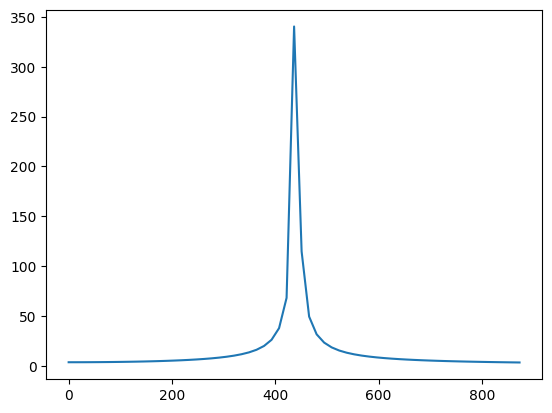

In [ ]:
#создадим пример с утечкой
signal = tdsp.SinSignal(freq=440)
duration = signal.period * 30.25
wave = signal.make_wave(duration)
spectrum = wave.make_spectrum()
spectrum.plot(high=880)

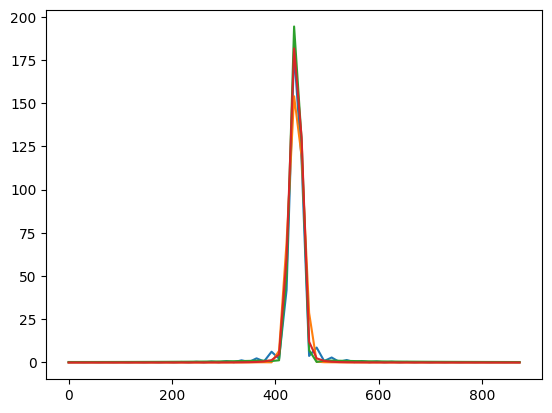

In [ ]:
#реализуем разные функции окон
for func in [np.bartlett, np.blackman, np.hamming, np.hanning]:
    wave = signal.make_wave(duration)
    wave.ys *= func(len(wave.ys))

    spectrum = wave.make_spectrum()
    spectrum.plot(high=880)

Каждая функция окна уменьшает утечку.

##Упражнение 3.2

Класс SawtoothChirp и спектрограмма, наблюдение биений.

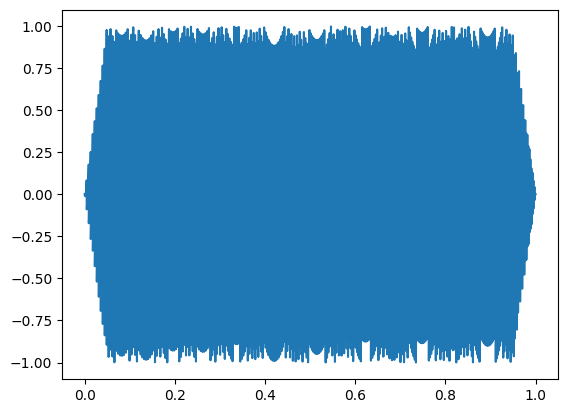

In [24]:
#класс SawtoothChirp

class SawtoothChirp(tdsp.Chirp):

    def evaluate(self, ts):
        freqs = np.linspace(self.start, self.end, len(ts))
        dts = np.diff(ts, prepend=0)
        dphis = np.pi * 2 * freqs * dts
        phases = np.cumsum(dphis)
        cycles = phases / (np.pi * 2 )
        frac, _ = np.modf(cycles)
        ys =  tdsp.normalize(tdsp.unbias(frac), self.amp)
        return ys


signal = SawtoothChirp(start=220, end=440)
wave = signal.make_wave(duration=1, framerate=5000)
wave.apodize()
wave.plot()
wave.make_audio()

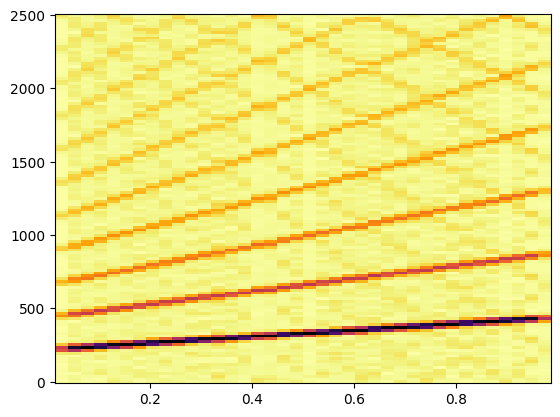

In [25]:
#спектрограмма
spectrogram = wave.make_spectrogram(256)
spectrogram.plot()

Можем видеть, как гармоники постепенно заворачиваются.

##Упражнение 3.3

Spectrum по пилообразному чирпу

In [26]:
#пилообразный чирп
signal = SawtoothChirp(start=2500, end=3000)
wave = signal.make_wave(duration=1, framerate=20000)
wave.make_audio()

Логически, так как основные гармоники 2500-3000Гц, следующие гармоники будут 5000-6000Гц и так далее.

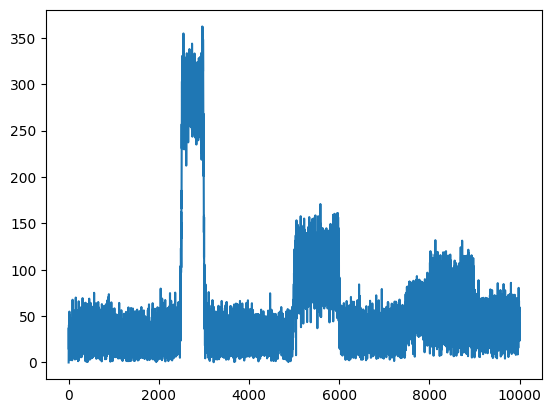

In [27]:
#spectrum
wave.make_spectrum().plot()

##Упражнение 3.4
Глиссандо и его спектрограмма

In [34]:
#добавляем запись глиссандо (взята из репозитория автора)
if not os.path.exists('72475__rockwehrmann__glissup02.wav'):
    !wget https://github.com/Dementrrr/ThinkDSP/raw/master/code/72475__rockwehrmann__glissup02.wav

In [36]:
#создаем wave
wave = tdsp.read_wave('72475__rockwehrmann__glissup02.wav')
wave.make_audio()

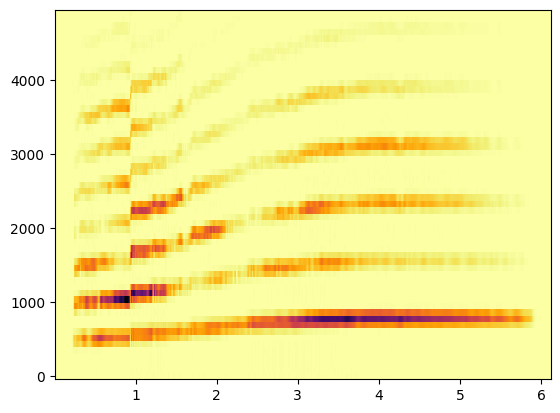

In [38]:
#создаем спектрограмму
wave.make_spectrogram(512).plot(high=5000)

##Упражнение 3.5
Глиссандо на трамбоне, класс TromboneGliss

In [67]:
#Класс TromboneGliss
class TromboneGliss(tdsp.Chirp):

    def evaluate(self, ts):
        #иммитируем тромбон, тогда отталкиваемся от длинн, которые обратно пропорциональны частоте
        l1, l2 = 1.0 / self.start, 1.0 / self.end
        lengths = np.linspace(l1, l2, len(ts))
        freqs = 1 / lengths

        dts = np.diff(ts, prepend=0)
        dphis = np.pi * 2 * freqs * dts
        phases = np.cumsum(dphis)
        ys = self.amp * np.cos(phases)
        return ys

c3 = 262
f3 = 349

signal = TromboneGliss(c3, f3)
wave1 = signal.make_wave(duration=1)

signal = TromboneGliss(f3, c3)
wave2 = signal.make_wave(duration=1)

wave = wave1 | wave2
wave.make_audio()

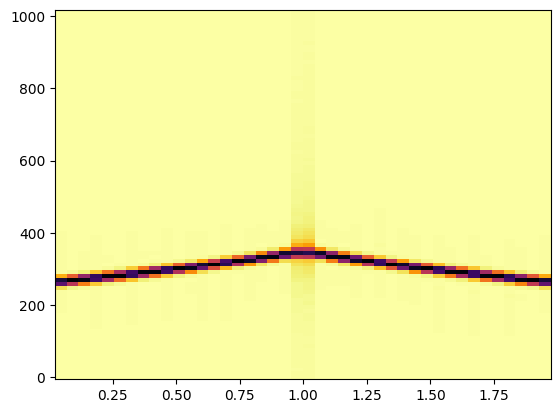

In [68]:
sp = wave.make_spectrogram(1024)
sp.plot(high=1024)

По форме спектрограммы можем видеть, что глиссандо на тромбоне ближе к **экпоненциальному чирпу**.

##Упражнение 3.6
Спектрограмма глассных звуков.
Аудиозапись записал сам на телефон, затем конвертировал в wav.

In [72]:
#получим запись звуков
if not os.path.exists('1__Dementrrr_vowels.wav'):
    !wget https://github.com/Dementrrr/ThinkDSP/raw/master/code/1__Dementrrr_vowels.wav

In [102]:
#создадим wave
wave = tdsp.read_wave('1__Dementrrr_vowels.wav')
wave.make_audio()

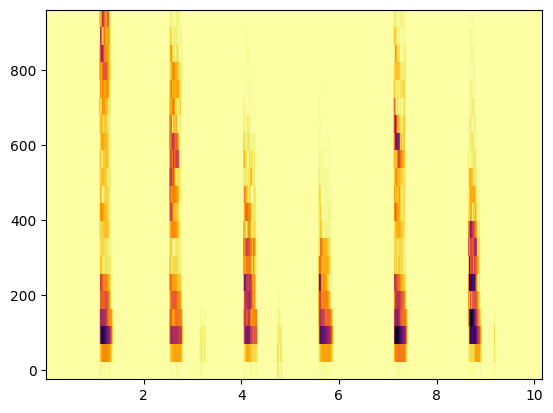

In [101]:
#создадим спектрограмму звуков
sp = wave.make_spectrogram(1024)
sp.plot(high=1000)

В этой записи по порядку записаны буквы А, О, У, И, Э, Ы. Рассмотрим каждый фрагмент записи отдельно, определим спектры.

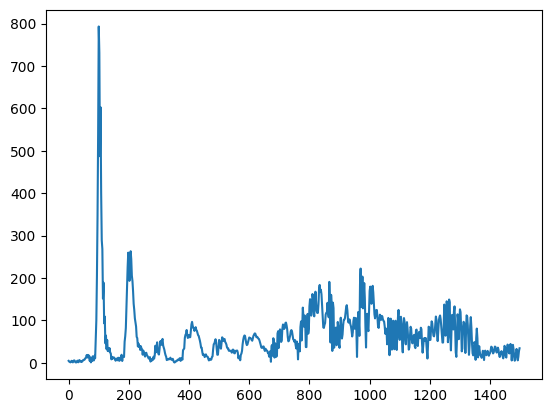

In [128]:
#А
segment_A = wave.segment(start=1, duration=0.5)

#спектр для А
spectrum_A = segment_A.make_spectrum()
spectrum_A.plot(high=1500)

segment_A.make_audio()

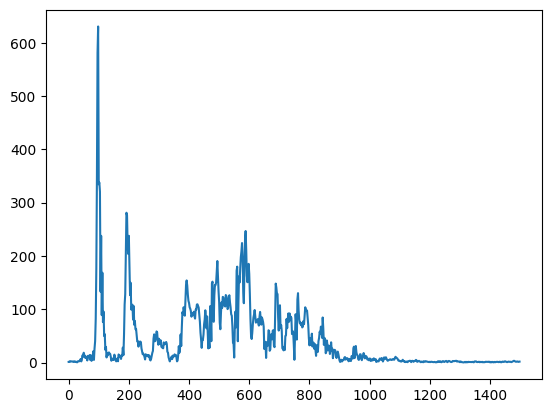

In [129]:
#О
segment_O = wave.segment(start=2.3, duration=0.5)

#спектр для О
spectrum_O = segment_O.make_spectrum()
spectrum_O.plot(high=1500)

segment_O.make_audio()

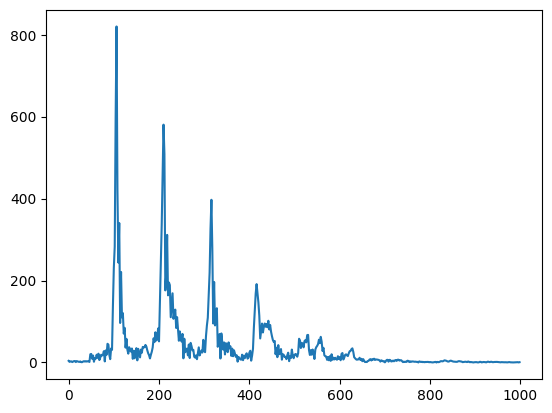

In [130]:
#У
segment_U = wave.segment(start=4, duration=0.5)

#спектр для У
spectrum_U = segment_U.make_spectrum()
spectrum_U.plot(high=1000)

segment_U.make_audio()

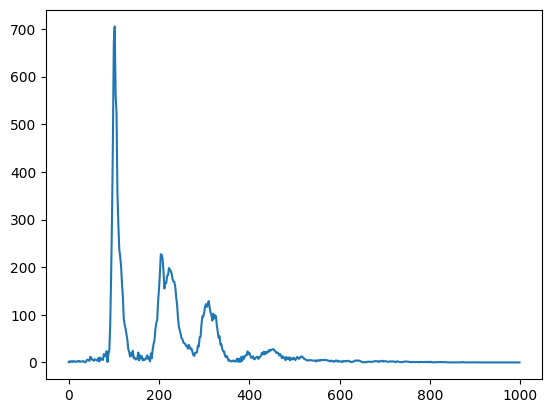

In [136]:
#И
segment_I = wave.segment(start=5.5, duration=0.5)

#спектр для И
spectrum_I = segment_I.make_spectrum()
spectrum_I.plot(high=1000)

segment_I.make_audio()

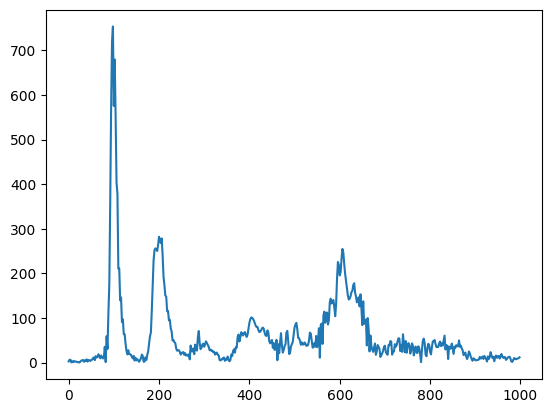

In [132]:
#Э
segment_E = wave.segment(start=7.1, duration=0.5)

#спектр для Э
spectrum_E = segment_E.make_spectrum()
spectrum_E.plot(high=1000)

segment_E.make_audio()

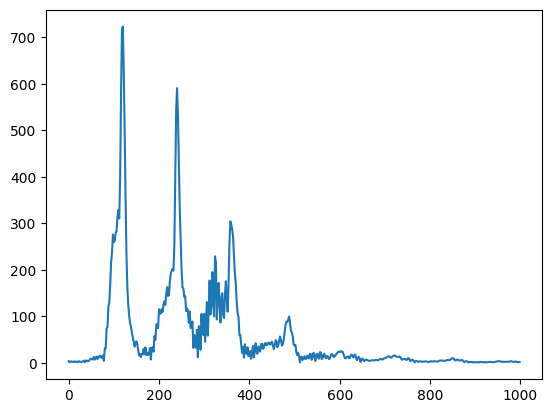

In [133]:
#Ы
segment_Y = wave.segment(start=8.5, duration=0.5)

#спектр для Ы
spectrum_Y = segment_Y.make_spectrum()
spectrum_Y.plot(high=1000)

segment_Y.make_audio()

Можем увидеть, что основная частота для всех букв примерно 100Гц, можем видеть гармоники на 200, 300,400Гц.

Различаются же буквы в основном дальше по спектру, у каждой из них есть свой интервал, в котором возникает звучание.

Так для А это интервал 800-1400Гц,
О - 400-800Гц,
У - 200-600Гц,
Э - 400-700Гц,
Ы - 200-400Гц, у буквы И нету четко выраженного интервала.

В целом по спектрам можно отличить буквы друг от друга.